# Lennard-Jones Fluid Coexistence via fvGEMC

Computes liquid–vapor coexistence densities for the truncated Lennard-Jones fluid with the
Fixed-Volume variant of Gibbs Ensemble Monte Carlo (fvGEMC): a set of short, fixed-volume
GEMC runs, with results fit to recover the coexistence densities, just like regular GEMC.

1. **Simulate** — run fvGEMC for a set of (initial density, temperature) pairs.
2. **Fit** — reshape results into one finite-volume family per temperature, then fit to recover the true coexistence densities.
3. **Compare** — plot against a direct, long-run reference GEMC simulation.

Setup, GEMC engine, and Fitting engine below are collapsed by default — they're reusable
library code, not required reading to follow the analysis.

## Setup

This notebook needs a Julia kernel to execute. Colab (and any well-behaved notebook host)
picks it up automatically from this notebook's metadata; if yours doesn't, select **Julia**
manually.

Run this section once to install the required packages (`Plots`, `LsqFit`, `Optim`) and
prepare the kernel, then run the rest of the notebook normally.

Everything runs inside this notebook except package installation, which needs network access.

In [1]:
import Pkg
for pkg in ["Plots", "LsqFit", "Optim"]
    isnothing(Base.find_package(pkg)) && Pkg.add(pkg)
end

using Printf, LsqFit, Optim, DelimitedFiles, Statistics, Plots

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed NLSolversBase ──────────── v8.0.0
   Installed FiniteDiff ─────────────── v2.32.0
   Installed LsqFit ─────────────────── v0.16.1
   Installed DifferentiationInterface ─ v0.7.20
    Updating `~/.julia/environments/v1.12/Project.toml`
  [2fda8390] + LsqFit v0.16.1
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [a0c0ee7d] + DifferentiationInterface v0.7.20
  [6a86dc24] + FiniteDiff v2.32.0
  [2fda8390] + LsqFit v0.16.1
  [d41bc354] + NLSolversBase v8.0.0
Precompiling packages...
   9895.8 ms  ✓ FiniteDiff
  12792.7 ms  ✓ DifferentiationInterface
   2319.4 ms  ✓ FiniteDiff → FiniteDiffStaticArraysExt
   2614.9 ms  ✓ DifferentiationInterface → DifferentiationInterfaceStaticArraysExt
   2793.1 ms  ✓ FiniteDiff → FiniteDiffSparseArraysExt
   1163.2 ms  ✓ DifferentiationInterface → DifferentiationInterfaceGPUArraysCoreExt
   1447.9 ms  ✓ DifferentiationInterface → Differentiat

In [2]:
ENV["GKSwstype"] = "100"   # headless plotting (no display server)
SCRATCHDIR = mktempdir()   # per-thread input files for the GEMC engine's file-based interface;
                           # nothing produced by a run needs to persist, so this is the only path we need

println("Julia threads available: ", Threads.nthreads(), "  (Sys.CPU_THREADS = ", Sys.CPU_THREADS, ")")

Julia threads available: 2  (Sys.CPU_THREADS = 2)


## GEMC engine

A Gibbs Ensemble Monte Carlo engine for the truncated (`rc=3σ`) Lennard-Jones fluid: particle
translation, volume-exchange, and particle-swap moves between two boxes, with adaptively-tuned
step sizes. `main(infile, outfile, posfile)` runs one simulation and returns the dilute and
dense box densities (`rho1`, `rho2`), averaged over the second half of the run
(post-equilibration). The same engine produced the reference GEMC densities below, in a separate,
longer run; those results are precomputed and hardcoded rather than generated live here.

In [3]:
# Minimum-image convention: box coordinates are stored in [-0.5, 0.5); wrap()
# folds a coordinate difference back into that range so a distance never exceeds L/2.
wrap(x) = x - round(x)

mutable struct LCG
    state::Vector{Int64}
end
LCG(seed::Integer) = LCG(fill(Int64(seed), Threads.maxthreadid()))
const RNG = LCG(0)

function rand(rng::LCG)
    i = Threads.threadid()
    rng.state[i] = (rng.state[i] * 1103515245 + 12345) & 0x7fffffff
    rng.state[i] / 2147483647.0
end
rand(rng::LCG, ::Type{Bool})      = rand(rng) < 0.5
rand(rng::LCG, r::UnitRange{Int}) = r.start + min(floor(Int, rand(rng) * length(r)), length(r)-1)
rand(rng::LCG, n::Int)            = [rand(rng) for _ in 1:n]

# ── Box ──

mutable struct Box
    pos::Vector{NTuple{3,Float64}}   # particle positions, fractional box coordinates in [-0.5, 0.5)
    L::Float64                       # box side length
    rc2::Float64                     # squared cutoff radius, real units (same scale as L, not fractional)
    erc::Float64                     # LJ energy at the cutoff, subtracted so the potential is continuous there
    js::Float64                      # translation step size, real units (same scale as L), adaptively tuned by adjust_step!
    ntry::Int                        # translation move attempts since the last adjust_step! call
    naccept::Int                     # translation move acceptances since the last adjust_step! call
end

# ── Energy ──

function lj(b::Box, p1, p2)
    r2 = sum(wrap.(p1 .- p2) .^ 2) * b.L^2
    r2 > b.rc2 && return 0.0
    r6 = 1/r2^3
    return 4*r6*(r6 - 1) - b.erc
end

function particle_energy(b::Box, p, skip::Int)
    e = 0.0
    for j in eachindex(b.pos)
        j == skip && continue
        e += lj(b, p, b.pos[j])
    end
    return e
end

total_energy(b::Box) = let n = length(b.pos), e = 0.0
    for i in 1:n-1, j in i+1:n
        e += lj(b, b.pos[i], b.pos[j])
    end
    e
end

get_V(b::Box)   = b.L^3
get_rho(b::Box) = length(b.pos) / get_V(b)
get_N(b::Box)   = length(b.pos)

# ── Lattice init ──

function make_box(N::Int, L::Float64, rc::Float64)
    rc6 = (1/rc)^6
    erc = 4*rc6*(rc6 - 1)
    pos = NTuple{3,Float64}[]
    n   = ceil(Int, cbrt(N))
    for i in 0:n-1, j in 0:n-1, k in 0:n-1
        length(pos) == N && break
        push!(pos, ((i+0.5)/n - 0.5, (j+0.5)/n - 0.5, (k+0.5)/n - 0.5))
    end
    return Box(pos, L, rc^2, erc, 0.005, 0, 0)
end

# ── Translation move ──

function mcmove!(b::Box, beta::Float64)
    n = length(b.pos)
    n == 0 && return
    b.ntry += 1
    i   = rand(RNG, 1:n)
    old = b.pos[i]
    eo  = particle_energy(b, old, i)
    new = old .+ Tuple((b.js/b.L) .* (rand(RNG, 3) .- 0.5))
    en  = particle_energy(b, new, i)
    if rand(RNG) < exp(-beta*(en - eo))
        b.pos[i] = new
        b.naccept += 1
    end
    b.ntry % 1000 == 0 && adjust_step!(b)
end
mcmove!(e1::Box, e2::Box, beta::Float64) =
    rand(RNG, Bool) ? mcmove!(e1, beta) : mcmove!(e2, beta)

function adjust_step!(b::Box)
    ratio = b.naccept / b.ntry
    ratio < 0.5 ? (b.js > 1e-6 && (b.js *= 0.99)) : (b.js < 1.0 && (b.js *= 1.01))
    b.ntry = b.naccept = 0
end

# ── Volume move ──

mutable struct VolState
    vstep::Float64   # log-volume-ratio move step size, adaptively tuned in mcvol!
    vtry::Int        # volume move attempts since the last step-size adjustment
    vaccept::Int     # volume move acceptances since the last step-size adjustment
end

function mcvol!(b1::Box, b2::Box, Vtot::Float64, vs::VolState, beta::Float64)
    vs.vtry += 1
    v1, v2   = get_V(b1), get_V(b2)
    n1, n2   = length(b1.pos), length(b2.pos)
    e1o, e2o = total_energy(b1), total_energy(b2)

    lnv = log(v1/v2) + vs.vstep*(rand(RNG) - 0.5)
    v1n = Vtot*exp(lnv)/(1 + exp(lnv))
    v2n = Vtot - v1n
    L1o, L2o = b1.L, b2.L
    b1.L, b2.L = cbrt(v1n), cbrt(v2n)

    e1n, e2n = total_energy(b1), total_energy(b2)
    arg = -beta*((e1n - e1o) + (e2n - e2o)) +
          (n1 + 1)*log(v1n/v1) + (n2 + 1)*log(v2n/v2)

    if rand(RNG) >= exp(arg)
        b1.L, b2.L = L1o, L2o
    else
        vs.vaccept += 1
    end

    if vs.vtry % 200 == 0
        ratio = vs.vaccept / vs.vtry
        ratio < 0.5 ? (vs.vstep *= 0.9) : (vs.vstep *= 1.1)
        vs.vtry = vs.vaccept = 0
    end
end

# ── Swap move ──

function mcswap!(e1::Box, e2::Box, mu::Vector{Float64}, beta::Float64)
    boxes = (e1, e2)
    dst_i = rand(RNG, Bool) ? 1 : 2; src_i = 3-dst_i
    dst, src = boxes[dst_i], boxes[src_i]
    n_dst, n_src = length(dst.pos), length(src.pos)
    v_dst, v_src = get_V(dst), get_V(src)

    trial = Tuple(rand(RNG, 3) .- 0.5)
    e_add = particle_energy(dst, trial, 0)
    mu[dst_i] += v_dst * exp(-beta*e_add) / (n_dst + 1)   # Widom estimator

    n_src == 0 && return false
    i    = rand(RNG, 1:n_src)
    p    = src.pos[i]
    e_rm = particle_energy(src, p, i)

    arg = -beta*(e_add - e_rm) + log(v_dst*n_src / (v_src*(n_dst + 1)))
    if rand(RNG) < exp(arg)
        deleteat!(src.pos, i)
        push!(dst.pos, trial)
        return true
    end
    false
end

# ── Swap-rate adapter ──

mutable struct SwapAdapt
    n::Float64          # current swap attempts per adaptation window -- this is what note_swap! tunes
    maxn::Float64        # upper bound on n
    target::Float64      # target number of accepted swaps per window
    boundary::Float64    # relative tolerance around target before n is adjusted
    attempts::Int         # swap attempts so far in the current window
    accepted::Int         # swap acceptances so far in the current window
end

function note_swap!(sa::SwapAdapt, accepted::Bool)
    sa.attempts += 1; accepted && (sa.accepted += 1)
    if sa.attempts >= max(1, round(Int, sa.n))
        if     sa.accepted > sa.target*(1+sa.boundary); sa.n *= 0.95
        elseif sa.accepted < sa.target*(1-sa.boundary); sa.n *= 1.05; end
        sa.n = clamp(sa.n, 1.0, sa.maxn)
        sa.attempts = 0; sa.accepted = 0
    end
end

# ── Output ──

function report_stride(rep::Int)
    rep <= 100 && return 1
    10^(floor(Int, log10(rep-1))-1)
end
should_report(rep::Int) = rep % report_stride(rep) == 0

function sample!(out::IO, e1::Box, e2::Box, mu::Vector{Float64}, beta::Float64, nsteps::Int, rep::Int)
    println(out, rep, " ", get_rho(e1), " ", get_rho(e2), " ", get_N(e1), " ", get_N(e2), " ",
            get_V(e1), " ", get_V(e2), " ",
            -log(mu[1]/nsteps)/beta, " ", -log(mu[2]/nsteps)/beta, " ",
            total_energy(e1), " ", total_energy(e2))
    flush(out)
end

function write_exp!(out2::IO, e1::Box, e2::Box, nsteps::Int, do_steps::Int)
    println(out2, "#L=", 0.5*e2.L, "; step ", nsteps/do_steps)
    for p in e2.pos
        ip = wrap.(p)
        println(out2, ip[1]*e2.L, " ", ip[2]*e2.L, " ", ip[3]*e2.L, " 0.5 1")
    end
    for p in e1.pos
        ip = wrap.(p)
        println(out2, ip[1]*e1.L + e2.L + e1.L, " ", ip[2]*e1.L, " ", ip[3]*e1.L, " 0.5 2")
    end
end

# ── GEMC run ──

function gemc(e1::Box, e2::Box, Vtot::Float64, beta::Float64, ntotal::Int, do_steps::Int,
              nrep::Int, even_out::Bool, nequil::Int, outfile::String, posfile::String;
              npart::Int, nvol::Int, nswap0::Float64, nswap_max::Float64,
              swap_target::Float64, swap_boundary::Float64)

    vs = VolState(0.1, 0, 0)
    sa = SwapAdapt(nswap0, nswap_max, swap_target, swap_boundary, 0, 0)
    mu = zeros(2); nsteps = 0
    s1 = s2 = 0.0; nacc = 0

    out  = open(outfile, "w")
    out2 = open(posfile,  "w")

    while nsteps < do_steps
        nsteps += 1
        nswap_now = max(1, round(Int, sa.n))
        R = rand(RNG, 1:(npart+nvol+nswap_now))
        if R <= npart
            mcmove!(e1, e2, beta)
        elseif R <= npart+nvol
            mcvol!(e1, e2, Vtot, vs, beta)
        else
            accepted = mcswap!(e1, e2, mu, beta)
            note_swap!(sa, accepted)
        end
        if nsteps % nrep == 0
            cycle = nsteps ÷ ntotal
            rep   = nsteps ÷ nrep
            if even_out || should_report(rep)
                sample!(out, e1, e2, mu, beta, nsteps, cycle)
                if cycle > nequil
                    r1, r2 = minmax(get_rho(e1), get_rho(e2))
                    s1 += r1; s2 += r2; nacc += 1
                end
            end
        end
    end

    write_exp!(out2, e1, e2, nsteps, do_steps)
    close(out); close(out2)
    rho1, rho2 = nacc > 0 ? (s1/nacc, s2/nacc) : (NaN, NaN)
    return (rho1=rho1, rho2=rho2, e1=e1, e2=e2)
end

# ── Main ──

function main(infile="read.in", outfile="data.out", posfile="p.dat";
              npart::Int=3000, nvol::Int=15,
              nswap0::Float64=3000.0, nswap_max::Float64=10_000.0,
              swap_target::Float64=1.0, swap_boundary::Float64=0.025)

    # infile holds 9 whitespace-separated values, one per line, in order:
    # T ntotal rho0 v1r rc bs ncycles seed nvol
    toks = split(read(infile, String))
    idx  = Ref(1)
    grab(::Type{T}) where T = (v = parse(T, toks[idx[]]); idx[] += 1; v)

    T       = grab(Float64)
    ntotal  = grab(Int)
    rho0    = grab(Float64)
    v1r     = grab(Float64)
    rc      = grab(Float64)
    bs      = grab(Int)
    ncycles = grab(Int)
    seed    = grab(Int)
    nvol    = grab(Int)
    RNG.state[Threads.threadid()] = seed
    N1 = round(Int, ntotal * v1r); N2 = ntotal - N1
    Vtot = ntotal / rho0
    V1 = v1r * Vtot; V2 = Vtot - V1
    L1 = cbrt(V1);   L2 = cbrt(V2)
    n1 = ceil(Int, cbrt(N1)); n2 = ceil(Int, cbrt(N2))
    (L1 >= n1 && L2 >= n2) || error("density too high: L1=$L1 n1=$n1, L2=$L2 n2=$n2")
    beta = 1.0/T
    do_steps = ncycles * ntotal
    nequil = ncycles ÷ 2   # average densities over the second half of the run (post-equilibration)
    println("beta=", beta, " v1r=", v1r, " rho0=", rho0)

    e1 = make_box(N1, L1, rc)
    e2 = make_box(N2, L2, rc)

    # bs < 0: even-interval output every |bs| cycles (ntotal*|bs| steps)
    # bs > 0: log-spaced output, same block size ntotal*bs steps
    even_out = bs < 0
    nrep = ntotal * abs(bs)

    return gemc(e1, e2, Vtot, beta, ntotal, do_steps, nrep, even_out, nequil, outfile, posfile;
                npart=npart, nvol=nvol, nswap0=nswap0, nswap_max=nswap_max,
                swap_target=swap_target, swap_boundary=swap_boundary)
end

main (generic function with 4 methods)

## Fitting engine

Each fixed-volume GEMC run at a given initial density only approximates the true
coexistence densities; running the same setup across many initial densities gives a
family of results that can be fit to recover them more precisely. This engine filters
out unreliable points, fits a curve to the dilute branch (the dense branch follows from
mass conservation), and refines the fit by removing outliers. `run_fit(x, y, y2; ...)`
is the entry point, returning the fitted `(x_mean, y_mean, y2_mean)` coexistence densities.

In [4]:
# ── Non-uniform-grid gradient, matching numpy.gradient's central-difference scheme ──
function gradient1d(y::AbstractVector, x::AbstractVector)
    n = length(y)
    g = zeros(Float64, n)
    n == 1 && return g
    g[1]   = (y[2] - y[1]) / (x[2] - x[1])
    g[end] = (y[end] - y[end-1]) / (x[end] - x[end-1])
    for i in 2:n-1
        hs = x[i] - x[i-1]
        hd = x[i+1] - x[i]
        g[i] = (hs^2*y[i+1] + (hd^2 - hs^2)*y[i] - hd^2*y[i-1]) / (hs*hd*(hs+hd))
    end
    return g
end

trapz(y, x) = sum((x[i+1]-x[i]) * (y[i]+y[i+1]) / 2 for i in 1:length(x)-1)


"""Optional warm start: parse previously fitted parameter sets out of a saved run
log, for use as `_best_opt`'s initial guesses."""
function read_initial_params_from_log(log_file)
    params_list = Vector{Vector{Float64}}()
    try
        content = read(log_file, String)
        # Match this cell's own "a=..; b=..; c=.." / "d=..; e=..; f=.." print format
        # (see _print_params below).
        abc  = collect(eachmatch(r"a=([\d.]+);\s*b=([\d.]+);\s*c=([\d.]+)", content))
        def_ = collect(eachmatch(r"d=([\d.]+);\s*e=([\d.]+);\s*f=([\d.]+)", content))
        if length(abc) == length(def_)
            for (m1, m2) in zip(abc, def_)
                push!(params_list, vcat(parse.(Float64, m1.captures), parse.(Float64, m2.captures)))
            end
        end
        println("Read $(length(params_list)) parameter set(s) from $log_file")
    catch ex
        println("Warning: $ex")
    end
    return params_list
end


function print_derivative_table(x, y, y2)
    fwd  = diff(y) ./ diff(x)
    dy   = vcat(fwd, fwd[end])          # forward diff; last point reuses n-2 value
    dy2  = gradient1d(y2, x)
    d2y2 = gradient1d(dy2, x)
    w = 73
    println("\nDerivative Table [y=forward-diff, y2=gradient]:")
    println("="^w)
    @printf("%3s %8s %10s %10s %12s %12s %12s\n", "idx", "x", "y", "y2", "dy/dx", "dy2/dx", "d2y2/dx2")
    println("-"^w)
    for i in eachindex(x)
        @printf("%3d %8.3f %10.6f %10.6f %12.6f %12.6f %12.6f\n",
                i - 1, x[i], y[i], y2[i], dy[i], dy2[i], d2y2[i])
    end
    println("="^w)
    println("Filter guide: transition = dy/dx sign-change nearest min(y); " *
             "lo = first point whose slope no longer exceeds mean+3σ of the negative " *
             "slopes before min(y); trim hi from right while d²y2/dx² > 0.")
end


"""Drop points where phase separation was incomplete: a much-smaller-than-neighbors
|y-y2| width means the two boxes hadn't separated from each other when sampled (rho1
and rho2 came out close instead of distinctly dilute/dense). Runs before filter_data
so these don't skew the transition/trim logic there."""
function filter_near_diagonal(x, y, y2)
    n = length(x)
    keep = trues(n)
    prev = 1   # nearest surviving neighbor before i; walks back past any point already removed
    for i in 2:n-1
        # reject i if its width is less than half the smaller of its two neighbors' widths
        gap        = abs(y[i] - y2[i])
        gap_before = abs(y[prev] - y2[prev])
        gap_after  = abs(y[i+1] - y2[i+1])
        if gap < min(gap_before, gap_after) / 2
            keep[i] = false
        else
            prev = i
        end
    end
    removed = n - count(keep)
    if removed > 0
        println("Diagonal-proximity filter: removed $removed/$n point(s) with |y-y2| gap < half its smaller neighbor gap")
    end
    return x[keep], y[keep], y2[keep]   # endpoints 1 and n are always kept; filter_data trims those
end


"""Return (x_filtered, y_filtered, y2_filtered) covering the coexistence region."""
function filter_data(x, y, y2)
    n = length(x)
    fwd  = diff(y) ./ diff(x)
    dy   = vcat(fwd, fwd[end])
    d2y2 = gradient1d(gradient1d(y2, x), x)

    # Transition: sign-change in dy nearest to y minimum
    min_idx = argmin(y)
    trans, best = min_idx, Inf
    for i in 2:n-1
        if dy[i-1] < 0 && dy[i] >= 0
            d = abs(y[i] - y[min_idx])
            if d < best
                best, trans = d, i
            end
        end
    end

    # Low start: no negative-slope point -> keep everything. A single negative-slope point
    # -> reject everything before it. Multiple negative-slope points -> take the mean/SD of
    # the negative slopes preceding the y-minimum, then reject from the low end while
    # slope > mean + 3*SD, stopping at the first point that no longer exceeds the threshold.
    neg_idx = findall(i -> dy[i] < 0, 1:n)
    lo = 1
    if length(neg_idx) == 1
        lo = neg_idx[1]
    elseif length(neg_idx) > 1
        preceding = filter(i -> i < min_idx, neg_idx)
        if !isempty(preceding)
            mu  = mean(dy[preceding])
            sig = length(preceding) > 1 ? std(dy[preceding]; corrected=false) : abs(mu) * 0.1
            for i in 1:n
                if dy[i] <= mu + 3*sig
                    lo = i
                    break
                end
            end
        end
    end

    # High end: trim from right while d²y2/dx² > 0. The very last point can
    # be a false negative (a numerical dip) — if the point before it is
    # positive, treat the last point as positive too.
    hi = n
    check_start = min(n, trans + 2)
    for i in n:-1:check_start
        positive = d2y2[i] > 0 || (i == n && n > 1 && d2y2[n-1] > 0)
        if positive
            hi = i
        else
            break
        end
    end

    lo = max(1, min(lo, trans))
    hi = min(n, max(hi, trans))
    println("Filtered range: [$lo, $hi], keeping $(hi - lo + 1)/$n points")
    return x[lo:hi], y[lo:hi], y2[lo:hi]
end


"""Solve b*t^2 + (a-x)*t - c = 0 for the positive root."""
function solve_t(x, a, b, c)
    disc = max.((a .- x).^2 .+ 4b*c, 0.0)
    return (-(a .- x) .+ sqrt.(disc)) ./ (2b)
end

# calc_y returns the y branch of the parametric hyperbola x=x(t), y=y(t); callers get the
# y2 branch from mass conservation (rho1 + rho2 = 2*rho0), i.e. y2 = 2x - y.
function calc_y(x, a, b, c, d, e, f)
    t = solve_t(x, a, b, c)
    return ifelse.(t .> 0, .-d .+ e .* t .+ f ./ t, 100.0)
end


function goodness_of_fit(y_data, y_fit; n_params=6)
    n = length(y_data)
    ss_res = sum((y_data .- y_fit).^2)
    ss_tot = sum((y_data .- mean(y_data)).^2)
    r2     = ss_tot > 0 ? 1.0 - ss_res / ss_tot : 0.0
    adj_r2 = 1.0 - (1.0 - r2) * (n - 1) / max(n - n_params - 1, 1)
    rmse   = sqrt(ss_res / n)
    return r2, adj_r2, rmse
end


function print_fit_quality(label, r2, adj_r2, rmse, n; n_params=6)
    @printf("\n%s (n=%d, params=%d):\n", label, n, n_params)
    n <= n_params && println("  WARNING: underdetermined (n ≤ n_params) — metrics unreliable")
    @printf("  R²=%.6f  adj.R²=%.6f  RMSE=%.4e\n", r2, adj_r2, rmse)
end


"""Return index of the point with the largest absolute residual."""
function find_outlier(x, y, p)
    y_fit = calc_y(x, p...)
    return argmax(abs.(y .- y_fit))
end


"""Print a Round 1 vs Round 2 comparison table; return true if removing the
outlier is justified."""
function compare_and_report(m1, m2, n1, n2; outlier_resid=nothing, n_params=6)
    r2_1, ar2_1, rmse_1 = m1
    r2_2, ar2_2, rmse_2 = m2
    d_rmse = (rmse_1 - rmse_2) / rmse_1 * 100

    @printf("\nFit comparison  (n=%d → n=%d after removing outlier):\n", n1, n2)
    @printf("  %-12s %12s %12s %12s\n", "Metric", "Round 1", "Round 2", "Delta")
    @printf("  %-12s %12.6f %12.6f %+12.6f\n", "R²", r2_1, r2_2, r2_2 - r2_1)
    @printf("  %-12s %12.6f %12.6f %+12.6f\n", "adj.R²", ar2_1, ar2_2, ar2_2 - ar2_1)
    @printf("  %-12s %12.4e %12.4e %+11.2f%%\n", "RMSE", rmse_1, rmse_2, d_rmse)

    if n2 <= n_params
        @printf("  WARNING: Round 2 underdetermined (n=%d ≤ %d); ΔRMSE≈100%% expected — coupled t constrains effective DoF.\n", n2, n_params)
    end

    if outlier_resid !== nothing && rmse_1 > 0
        nr   = abs(outlier_resid) / rmse_1
        frac = outlier_resid^2 / (n1 * rmse_1^2)
        @printf("  Outlier |resid|/RMSE=%.2f  error-share=%.1f%% (%.2fx fair)  [info only]\n",
                nr, frac * 100, frac * n1)
    end

    # Adaptive threshold: unlike |resid|/RMSE (which only measures the outlier's own
    # residual), ΔRMSE also catches cases where the outlier was suppressing the whole fit.
    threshold = 200.0 / n2
    justified = d_rmse > threshold
    @printf("  Verdict: %s  (ΔRMSE %+.2f%% > %.1f%% = 200/n2)\n",
            justified ? "JUSTIFIED" : "NOT justified", d_rmse, threshold)
    return justified
end


"""Simple single-panel plot: raw data (cross), accepted-fit data (empty
circle), the coexistence shaded region, and the x/y/y2 means (solid points)."""
function plot_fit_min(x_raw, y_raw, y2_raw, final_xf, final_yf, final_y2f, final_p, range_info, label; write_files=false)
    plt = plot(; xlabel="ρ'₀", ylabel="ρ'₁ or ρ'₂", legend=false, grid=false,
               xlim=(0.0, 0.7), ylim=(-0.1, 0.9),
               framestyle=:box, size=(360, 240), dpi=150)

    scatter!(plt, x_raw, y_raw; marker=:x, color=:steelblue)
    scatter!(plt, x_raw, y2_raw; marker=:x, color=:darkorange)

    xs_curve  = range(minimum(final_xf), maximum(final_xf), length=500)
    ys_curve  = calc_y(xs_curve, final_p...)
    y2s_curve = 2 .* xs_curve .- ys_curve
    plot!(plt, xs_curve, ys_curve; ls=:solid, color=:steelblue)
    plot!(plt, xs_curve, y2s_curve; ls=:solid, color=:darkorange)

    scatter!(plt, final_xf, final_yf; marker=:circle, markercolor=:white,
             markerstrokecolor=:steelblue)
    scatter!(plt, final_xf, final_y2f; marker=:circle, markercolor=:white,
             markerstrokecolor=:darkorange)

    if range_info !== nothing
        xs, si, ei, xm, ym, y2m, area = range_info
        if si !== nothing
            vspan!(plt, [xs[si], xs[ei]]; alpha=0.15, color=:green)
            scatter!(plt, [xm], [ym]; marker=:circle, color=:steelblue,
                     markerstrokecolor=:black)
            scatter!(plt, [xm], [y2m]; marker=:circle, color=:darkorange,
                     markerstrokecolor=:black)
        end
    end

    if write_files
        savefig(plt, label * ".min.png")
        println("Plot written to: $(label).min.png")
    end
    return plt
end


# ── Private helpers ──────────────────────────────────────────────────────────

function _default_init(xf, yf)
    xr, yr = maximum(xf) - minimum(xf), maximum(yf) - minimum(yf)
    return [xf[argmin(yf)], xr * 0.5, xr * 0.1, minimum(yf) * 0.5, yr * 2, yr * 0.2]
end

function _bounds(xf, yf)
    xr, yr = maximum(xf) - minimum(xf), maximum(yf) - minimum(yf)
    lb = [minimum(xf) * 0.5, 1e-6, 1e-6, 1e-6, 1e-6, 1e-6]
    ub = [maximum(xf) * 1.5, xr * 2, xr, abs(maximum(yf)) * 2, yr * 10, yr * 5]
    return lb, ub
end

"""Try all initial param sets against the bounded fit; return (best_params, best_error)."""
function _best_opt(init_list, xf, yf, lb, ub, tol)
    model(x, p) = calc_y(x, p[1], p[2], p[3], p[4], p[5], p[6])
    sse(p) = sum((yf .- model(xf, p)) .^ 2)
    best_p, best_e = nothing, Inf
    println("\nTrying $(length(init_list)) initial parameter set(s)...")
    for (i, init) in enumerate(init_list)
        init = Float64.(init)
        err, p = try
            # Bounded Levenberg-Marquardt (LsqFit) first -- the natural Julia analogue of
            # scipy's bounded trust-constr for this curve-fitting problem.
            fit = curve_fit(model, xf, yf, init; lower=lb, upper=ub, x_tol=tol, g_tol=tol)
            sum(fit.resid .^ 2), fit.param
        catch
            try
                # Falls back to derivative-free bounded Nelder-Mead when the Jacobian is
                # singular (common for rank-deficient rounds, e.g. Round 2 with n <= n_params).
                res = optimize(sse, lb, ub, init, Fminbox(NelderMead()),
                                Optim.Options(f_reltol=tol, iterations=5000))
                Optim.minimum(res), Optim.minimizer(res)
            catch ex
                println("  Set $i: failed ($ex)")
                continue
            end
        end
        better = err < best_e
        better && ((best_e, best_p) = (err, p))
        @printf("  Set %d: error=%.6e%s\n", i, err, better ? " (best)" : "")
    end
    best_p === nothing && error("All optimization attempts failed")
    return best_p, best_e
end

"""Index range of the longest segment where both dy>0 and dy2>0."""
function _positive_range(dy, dy2)
    both = (dy .> 0) .& (dy2 .> 0)
    any(both) || return nothing, nothing
    idx = findall(both)
    segs = Tuple{Int,Int}[]
    s = idx[1]
    for i in 2:length(idx)
        if idx[i] != idx[i-1] + 1
            push!(segs, (s, idx[i-1]))
            s = idx[i]
        end
    end
    push!(segs, (s, idx[end]))
    return segs[argmax([t[2] - t[1] for t in segs])]
end

function _print_params(p)
    a, b, c, d, e, f = p
    @printf("a=%.6f; b=%.6f; c=%.6f\n", a, b, c)
    @printf("d=%.6f; e=%.6f; f=%.6f\n", d, e, f)
end

function _print_t_range(xf, p)
    t = solve_t(xf, p[1], p[2], p[3])
    @printf("set tr [%.3f:%.3f]\n", minimum(t), maximum(t))
end


# method is a vestige of the Python prototype's scipy.optimize(method="trust-constr") call;
# _best_opt below is a fixed reimplementation of that approach (bounded LsqFit, falling back
# to Nelder-Mead), so this kwarg is unused -- kept only as a note of where the fit came from.
function run_fit(x_data, y_data, y2_data; label="fit", method="trust-constr", tol=1e-9,
                  initial_params_file=nothing, use_recommendation=false, write_files=false)
    ord = sortperm(x_data)
    x_data, y_data, y2_data = x_data[ord], y_data[ord], y2_data[ord]
    x_raw, y_raw, y2_raw = x_data, y_data, y2_data   # before any filtering, for plotting
    x_data, y_data, y2_data = filter_near_diagonal(x_data, y_data, y2_data)

    print_derivative_table(x_data, y_data, y2_data)
    xf1, yf1, y2f1 = filter_data(x_data, y_data, y2_data)
    lb, ub = _bounds(xf1, yf1)

    init_list = _default_init(xf1, yf1)
    # unused by this notebook's default flow -- fit_temperature() never passes initial_params_file
    init_list = if initial_params_file !== nothing
        from_log = read_initial_params_from_log(initial_params_file)
        isempty(from_log) ? [init_list] : from_log
    else
        [init_list]
    end

    # ── Round 1 ───────────────────────────────────────────────────────────────
    p1, err1 = _best_opt(init_list, xf1, yf1, lb, ub, tol)
    @printf("\n── Round 1 (error=%.6e) ──\n", err1)
    _print_params(p1); _print_t_range(xf1, p1)
    yfit1 = calc_y(xf1, p1...)
    m1 = goodness_of_fit(yf1, yfit1)
    print_fit_quality("Round 1 goodness of fit", m1..., length(yf1))

    # ── Outlier detection (largest |residual|) ────────────────────────────────
    widx   = find_outlier(xf1, yf1, p1)
    resid1 = yf1 .- yfit1
    rmse1  = m1[3]
    println("\nOutlier analysis (largest |residual|):")
    @printf("  %-5s %8s %12s %12s %12s %10s\n", "[i]", "x", "y", "y_fit", "residual", "|r|/RMSE")
    for (i, (xi, yi, yfi, ri)) in enumerate(zip(xf1, yf1, yfit1, resid1))
        @printf("  [%d]  %8.4f %12.6f %12.6f %12.4e %10.2f%s\n",
                i - 1, xi, yi, yfi, ri, abs(ri) / rmse1, i == widx ? " ←" : "")
    end

    # ── Round 2 ───────────────────────────────────────────────────────────────
    @printf("\nRemoving outlier: index %d  x=%.4f  y=%.6f  |resid|=%.4e\n",
            widx - 1, xf1[widx], yf1[widx], abs(resid1[widx]))
    mask = trues(length(xf1)); mask[widx] = false
    xf2, yf2, y2f2 = xf1[mask], yf1[mask], y2f1[mask]

    p2, err2 = _best_opt([p1], xf2, yf2, _bounds(xf2, yf2)..., tol)
    @printf("\n── Round 2 (error=%.6e) ──\n", err2)
    _print_params(p2); _print_t_range(xf2, p2)
    yfit2 = calc_y(xf2, p2...)
    m2 = goodness_of_fit(yf2, yfit2)
    print_fit_quality("Round 2 goodness of fit", m2..., length(yf2))

    justified = compare_and_report(m1, m2, length(yf1), length(yf2);
                                    outlier_resid=resid1[widx])

    use_r2 = use_recommendation && justified
    local final_p, final_xf, final_yf, final_y2f
    if use_r2
        final_p, final_xf, final_yf, final_y2f = p2, xf2, yf2, y2f2
        println("\n→ Round 2 parameters accepted (use_recommendation=true, justified).")
    else
        final_p, final_xf, final_yf, final_y2f = p1, xf1, yf1, y2f1
        println("\n→ Round 1 parameters accepted.")
        if justified
            println("  Note: Round 2 was JUSTIFIED — re-run with use_recommendation=true to apply.")
        end
    end
    _print_params(final_p); _print_t_range(final_xf, final_p)

    # ── Range statistics and area ──────────────────────────────────────────────
    xs  = collect(range(minimum(final_xf), maximum(final_xf), length=500))
    ys  = calc_y(xs, final_p...)
    y2s = 2 .* xs .- ys
    dy  = gradient1d(ys, xs)
    dy2 = gradient1d(y2s, xs)
    si, ei = _positive_range(dy, dy2)
    xm = ym = y2m = area = nothing
    if si !== nothing
        xm  = mean(xs[si:ei])
        ym  = calc_y(xm, final_p...); y2m = 2xm - ym
        @printf("Range statistics: x_mean=%.6f, y_mean=%.6f, y2_mean=%.6f\n", xm, ym, y2m)
        diff_ = y2s[si:ei] .- ys[si:ei]
        area  = trapz(diff_, xs[si:ei])
        @printf("Area between curves: %.6f\n", area)
    end
    range_info = (xs, si, ei, xm, ym, y2m, area)

    if write_files
        smooth_file = label * ".xysmooth.txt"
        open(smooth_file, "w") do io
            println(io, "#x_smooth y_smooth y2_smooth")
            writedlm(io, hcat(xs, ys, y2s))
        end
        if si !== nothing && xm !== nothing
            open(smooth_file, "a") do io
                @printf(io, "#x_start %.10g\n#x_end %.10g\n#mean %.10g %.10g %.10g\n",
                        xs[si], xs[ei], xm, ym, y2m)
            end
        end
        println("Smooth curve written to: $smooth_file")
    end

    fig = plot_fit_min(x_raw, y_raw, y2_raw, final_xf, final_yf, final_y2f, final_p, range_info, label; write_files=write_files)

    return (x_mean=xm, y_mean=ym, y2_mean=y2m, x_smooth=xs, y_smooth=ys, y2_smooth=y2s, fig=fig)
end

run_fit (generic function with 1 method)

## 1. Simulate

In [5]:
rho0_set = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]   # initial densities to sample
# Trimmed for Colab (2 threads): default to a single temperature so a full run finishes
# in reasonable time. Restore the full sweep by uncommenting the line below.
temps     = [0.85]
# temps   = [0.65, 0.75, 0.85, 0.95, 1.05]   # full sweep (5 temps, 45 sims total)
v1r_set = [0.5]   # box-1 volume fraction (of total volume); add more values to sweep it
vstr(v) = @sprintf("%.2f", v)
tstr(T) = @sprintf("%.2f", T)

tstr (generic function with 1 method)

`run_sims` defaults to `true` below, so this notebook runs the fvGEMC simulations (`N=512`,
`10 000` cycles each) over the `v1r_set × rho0_set × temps` set — **9 simulations for the
default single temperature** (T=0.85). On Colab's shared, 2-thread CPU, the 9
simulations take about 6 minutes total. Each run's `(rho1, rho2)` pair — the dilute and
dense box densities — is kept only in memory, in the `phase` dict; nothing is written to disk,
so re-running this cell always recomputes the simulations from scratch.

Uncomment the full `temps` list in the cell above to run all 5 temperatures (45 sims total) —
expect roughly 5x longer, about half an hour, on Colab's 2 threads.

In [6]:
run_sims = true  # default: run the simulations; change to false to skip them

true

In [7]:
function simulate(v1r, rho0, T; ntotal=512, rc=3.0, bs=1, ncycles=10_000, seed=1, nvol=0)
    # ncycles=1e4 for speed; the paper uses 1e5, but 1e4 is likely enough (see paper Fig. 7)
    infile = joinpath(SCRATCHDIR, "read_$(Threads.threadid()).in")
    write(infile, "$(tstr(T))\n$ntotal\n$(vstr(rho0))\n$(vstr(v1r))\n$rc\n$bs\n$ncycles\n$seed\n$nvol\n")
    main(infile, "/dev/null", "/dev/null")   # per-step trajectory/position dumps aren't used downstream
end

simulate (generic function with 1 method)

In [8]:
begin
    phase = Dict{Tuple{Float64,Float64,Float64},NamedTuple}()
    local log = IOBuffer()
    local loglock = ReentrantLock()
    if run_sims
        local todo = [(v1r, rho0, T) for v1r in v1r_set for rho0 in rho0_set for T in temps]
        println(log, "simulating $(length(todo)) (v1r, rho0, T) combo(s) across $(Threads.nthreads()) thread(s)...")
        # :static pins each task to one thread for its whole lifetime -- required because the
        # GEMC engine's RNG keeps one mutable state slot per Threads.threadid(); a task that
        # migrated mid-run would corrupt whichever slot it landed on.
        Threads.@threads :static for i in eachindex(todo)
            v1r, rho0, T = todo[i]
            result = simulate(v1r, rho0, T)
            lock(loglock) do
                phase[(v1r, rho0, T)] = result
                println(log, "  done v1r=$(vstr(v1r)) rho0=$(vstr(rho0)) T=$(tstr(T)) (thread $(Threads.threadid()))")
            end
        end
        println(log, "done.")
    else
        println(log, "run_sims unchecked — phase left empty (nothing to compare/fit against).")
    end
    Text(String(take!(log)))
end

beta=1.1764705882352942 v1r=0.5 rho0=0.45
beta=1.1764705882352942 v1r=0.5 rho0=0.2
beta=1.1764705882352942 v1r=0.5 rho0=0.25
beta=1.1764705882352942 v1r=0.5 rho0=0.5
beta=1.1764705882352942 v1r=0.5 rho0=0.3
beta=1.1764705882352942 v1r=0.5 rho0=0.55
beta=1.1764705882352942 v1r=0.5 rho0=0.35
beta=1.1764705882352942 v1r=0.5 rho0=0.6
beta=1.1764705882352942 v1r=0.5 rho0=0.4


simulating 9 (v1r, rho0, T) combo(s) across 2 thread(s)...
  done v1r=0.50 rho0=0.20 T=0.85 (thread 2)
  done v1r=0.50 rho0=0.45 T=0.85 (thread 3)
  done v1r=0.50 rho0=0.25 T=0.85 (thread 2)
  done v1r=0.50 rho0=0.50 T=0.85 (thread 3)
  done v1r=0.50 rho0=0.30 T=0.85 (thread 2)
  done v1r=0.50 rho0=0.55 T=0.85 (thread 3)
  done v1r=0.50 rho0=0.35 T=0.85 (thread 2)
  done v1r=0.50 rho0=0.60 T=0.85 (thread 3)
  done v1r=0.50 rho0=0.40 T=0.85 (thread 2)
done.


## 2. Fit

Reshapes the simulation set into one finite-volume family per temperature, then
fits each family to the true coexistence densities.

### Prepare

`v1r_set` and `rho0_set` collapse into one flat family per temperature: every `(v1r, rho0)`
pair contributes an additional `(avg_density, rho1, rho2)` point to that temperature's
fit, the same way varying `rho0` alone did with a single fixed `v1r`.

In [9]:
function family_curve(T)
    pts = NamedTuple[]
    for v1r in v1r_set, rho0 in rho0_set
        haskey(phase, (v1r, rho0, T)) || continue
        p = phase[(v1r, rho0, T)]
        push!(pts, (x=(p.rho1 + p.rho2) / 2, y=p.rho1, y2=p.rho2))
    end
    pts
end
families = Dict(T => family_curve(T) for T in temps)

Dict{Float64, Vector{NamedTuple}} with 1 entry:
  0.85 => [(x = 0.2, y = 0.0178438, y2 = 0.382156), (x = 0.25, y = 0.0151953, y…

### Run the fits

Fits every temperature in `temps` (~1s/temperature), one at a time.

In [10]:
function fit_temperature(T)
    pts = families[T]
    x  = [p.x for p in pts]
    y  = [p.y for p in pts]
    y2 = [p.y2 for p in pts]
    r = run_fit(x, y, y2; label="T$(tstr(T))", use_recommendation=true)
    (T=T, y_mean=r.y_mean, y2_mean=r.y2_mean, x_mean=r.x_mean, fig=r.fig)
end

fit_temperature (generic function with 1 method)

In [11]:
fits = NamedTuple[]
for T in temps
    push!(fits, fit_temperature(T))
end
fits


Derivative Table [y=forward-diff, y2=gradient]:
idx        x          y         y2        dy/dx       dy2/dx     d2y2/dx2
-------------------------------------------------------------------------
  0    0.200   0.017844   0.382156    -0.052969     2.052969     0.723437
  1    0.250   0.015195   0.484805    -0.125313     2.089141     0.035547
  2    0.300   0.008930   0.591070     0.012266     2.056523    -3.226562
  3    0.350   0.009543   0.690457     0.454766     1.766484   -11.233594
  4    0.400   0.032281   0.767719     1.678906     0.933164   -17.792188
  5    0.450   0.116227   0.783773     2.346563    -0.012734   -14.932813
  6    0.500   0.233555   0.766445     2.773672    -0.560117   -10.803125
  7    0.550   0.372238   0.727762     3.412422    -1.093047    -8.523047
  8    0.600   0.542859   0.657141     3.412422    -1.412422    -6.387500
Filter guide: transition = dy/dx sign-change nearest min(y); lo = first point whose slope no longer exceeds mean+3σ of the negative slope

1-element Vector{NamedTuple}:
 (T = 0.85, y_mean = 0.020476938915571414, y2_mean = 0.736236487938136, x_mean = 0.37835671342685373, fig = Plot{Plots.GRBackend() n=9})

### Per-temperature fit figures

Each panel: raw finite-volume points (×), the fitted dilute/dense branches, the
accepted-fit points (open circles), and the coexistence point (filled
circle) inside the shaded valid-density interval.

T = 0.85


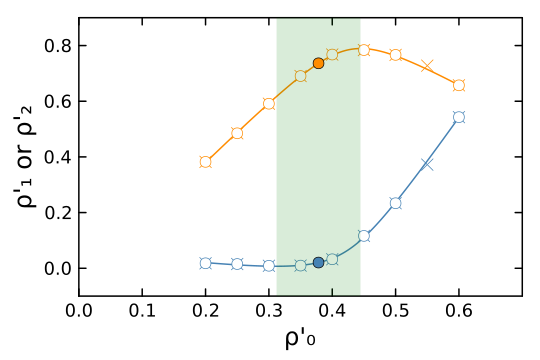

In [12]:
for f in fits
    println("T = $(f.T)")
    display(f.fig)
end

## 3. Compare

In [13]:
# From regular GEMC (volume exchange, 1e7 cycles), initial density 0.30.
reference_text = """0.65 0.0025877399877901074 0.8336377060664388
0.75 0.007081976643846621 0.7844437191798171
0.85 0.018394138677198774 0.7376365555365686
0.95 0.03983633225993487 0.676079771288953
1.05 0.07934873075315706 0.6004955675379813
"""
reference = [(T=parse(Float64, f[1]), rho1=parse(Float64, f[2]), rho2=parse(Float64, f[3]))
             for f in split.(split(reference_text, '\n', keepempty=false))]

5-element Vector{@NamedTuple{T::Float64, rho1::Float64, rho2::Float64}}:
 (T = 0.65, rho1 = 0.0025877399877901074, rho2 = 0.8336377060664388)
 (T = 0.75, rho1 = 0.007081976643846621, rho2 = 0.7844437191798171)
 (T = 0.85, rho1 = 0.018394138677198774, rho2 = 0.7376365555365686)
 (T = 0.95, rho1 = 0.03983633225993487, rho2 = 0.676079771288953)
 (T = 1.05, rho1 = 0.07934873075315706, rho2 = 0.6004955675379813)

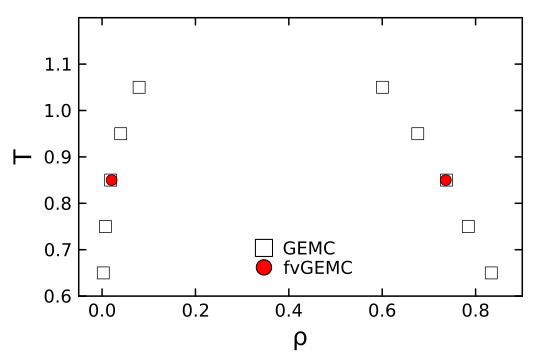

In [14]:
plt = plot(; xlabel="ρ", ylabel="T", legend=:bottom, grid=false,
           foreground_color_legend=nothing,
           xlim=(-0.05, 0.9), ylim=(0.6, 1.2),
           framestyle=:box, size=(360, 240), dpi=150)

# Reference: dilute + dense branches combined into one series, hollow markers, drawn first.
ref_rho = vcat([g.rho1 for g in reference], [g.rho2 for g in reference])
ref_T   = vcat([g.T for g in reference], [g.T for g in reference])
scatter!(plt, ref_rho, ref_T; label="GEMC",
         marker=:square, markercolor=:white, markerstrokecolor=:black)

# fvGEMC+fit: dilute + dense branches combined into one series, solid red circles, drawn on top.
if !isempty(fits)
    fv_rho = vcat([f.y_mean for f in fits], [f.y2_mean for f in fits])
    fv_T   = vcat([f.T for f in fits], [f.T for f in fits])
    scatter!(plt, fv_rho, fv_T; label="fvGEMC", marker=:circle, color=:red)
end

plt

In [15]:
let
    println(rpad("T", 6), rpad("fvGEMC dilute", 18), rpad("GEMC dilute", 18),
            rpad("fvGEMC dense", 18), "GEMC dense")
    for T in temps
        fT = findfirst(f -> f.T == T, fits)
        gT = findfirst(g -> g.T == T, reference)
        fs = fT === nothing ? "—" : @sprintf("%.6f", fits[fT].y_mean)
        fd = fT === nothing ? "—" : @sprintf("%.6f", fits[fT].y2_mean)
        gs = gT === nothing ? "—" : @sprintf("%.6f", reference[gT].rho1)
        gd = gT === nothing ? "—" : @sprintf("%.6f", reference[gT].rho2)
        println(rpad(tstr(T), 6), rpad(fs, 18), rpad(gs, 18), rpad(fd, 18), gd)
    end
end

T     fvGEMC dilute     GEMC dilute       fvGEMC dense      GEMC dense
0.85  0.020477          0.018394          0.736236          0.737637


The `fvGEMC` columns should closely track their `GEMC` counterparts at each temperature — that agreement demonstrates that the fixed-volume method faithfully reproduces its regular (volume-exchange) counterpart.